In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/user_reviews.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB
None


In [3]:
print(df.isnull().sum())

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [4]:
# Drop rows where 'Translated_Review' is NaN, as these are crucial for sentiment analysis
df_cleaned = df.dropna(subset=['Translated_Review'])

print(f"DataFrame shape after dropping NaNs: {df_cleaned.shape}")

DataFrame shape after dropping NaNs: (37427, 5)


In [5]:
# Display the distribution of Sentiment categories
print("Sentiment Distribution:")
print(df_cleaned['Sentiment'].value_counts())

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


The `Sentiment` column already provides the emotional tone (Positive, Negative, Neutral). The `Sentiment_Polarity` and `Sentiment_Subjectivity` columns offer numerical insights into this tone. We can now visualize this distribution.

In [6]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[^"\w\s"]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = ' '.join([word for word in text.split() if word not in stop_words]) # Remove stop words
    return text

# Apply preprocessing to the 'Translated_Review' column
df_cleaned['Cleaned_Review'] = df_cleaned['Translated_Review'].apply(preprocess_text)

# Display the first few cleaned reviews
display(df_cleaned[['Translated_Review', 'Cleaned_Review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipykernel_2642/252250036.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Cleaned_Review'] = df_cleaned['Translated_Review'].apply(preprocess_text)


,Translated_Review,Cleaned_Review
0,I like eat delicious food. That's I'm cooking ...,like eat delicious food thats im cooking food ...
1,This help eating healthy exercise regular basis,help eating healthy exercise regular basis
3,Works great especially going grocery store,works great especially going grocery store
4,Best idea us,best idea us
5,Best way,best way


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Prepare the features (X) and target (y)
X = df_cleaned['Cleaned_Review']
y = df_cleaned['Sentiment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency

# Fit and transform the training data, then transform the test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Vectorization complete.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

TF-IDF Vectorization complete.
Shape of X_train_tfidf: (29941, 5000)
Shape of X_test_tfidf: (7486, 5000)


Now that our text data is vectorized and split, we can train a Multinomial Naive Bayes model, which is a good baseline for text classification tasks.

In [8]:
# Initialize and train the Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


After training the model, let's evaluate its performance on the test set.

In [9]:
# Make predictions on the test set
y_pred = naive_bayes_model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.7411

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.43      0.58      1654
     Neutral       0.83      0.11      0.19      1032
    Positive       0.72      0.98      0.83      4800

    accuracy                           0.74      7486
   macro avg       0.81      0.51      0.53      7486
weighted avg       0.77      0.74      0.69      7486



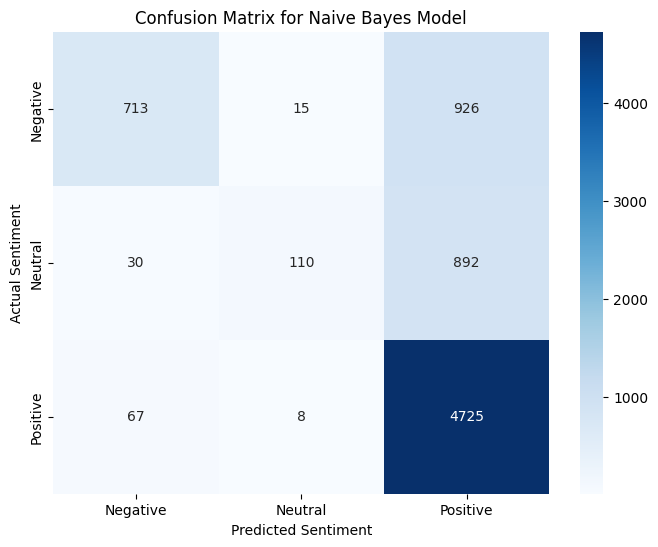

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix for Naive Bayes Model')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

/tmp/ipykernel_2642/3124312258.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df_cleaned, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


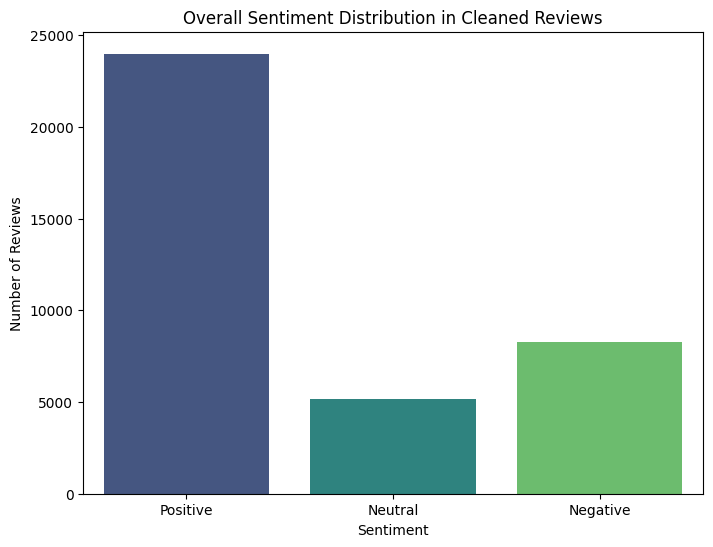

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot of the sentiment distribution from the cleaned DataFrame
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df_cleaned, palette='viridis', order=['Positive', 'Neutral', 'Negative'])
plt.title('Overall Sentiment Distribution in Cleaned Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### Test the Naive Bayes Model with New Reviews

Now, let's create a simple function to test our trained Naive Bayes model with new, unseen review texts. This function will:
1. Preprocess the input text using the same `preprocess_text` function we defined earlier.
2. Transform the cleaned text into TF-IDF features using the `tfidf_vectorizer`.
3. Use the `naive_bayes_model` to predict the sentiment of the review.


In [12]:
def predict_sentiment(review_text):
    # Preprocess the input text
    cleaned_text = preprocess_text(review_text)

    # Transform the cleaned text using the trained TF-IDF vectorizer
    text_tfidf = tfidf_vectorizer.transform([cleaned_text])

    # Predict the sentiment using the trained Naive Bayes model
    prediction = naive_bayes_model.predict(text_tfidf)

    return prediction[0]

# Test with some example reviews
example_review_1 = "This app is fantastic, I love all its features!"
example_review_2 = "It's okay, nothing special, just gets the job done."
example_review_3 = "Absolutely terrible, crashes all the time and is full of bugs."

print(f"Review 1: '{example_review_1}' -> Predicted Sentiment: {predict_sentiment(example_review_1)}")
print(f"Review 2: '{example_review_2}' -> Predicted Sentiment: {predict_sentiment(example_review_2)}")
print(f"Review 3: '{example_review_3}' -> Predicted Sentiment: {predict_sentiment(example_review_3)}")


Review 1: 'This app is fantastic, I love all its features!' -> Predicted Sentiment: Positive
Review 2: 'It's okay, nothing special, just gets the job done.' -> Predicted Sentiment: Positive
Review 3: 'Absolutely terrible, crashes all the time and is full of bugs.' -> Predicted Sentiment: Negative
